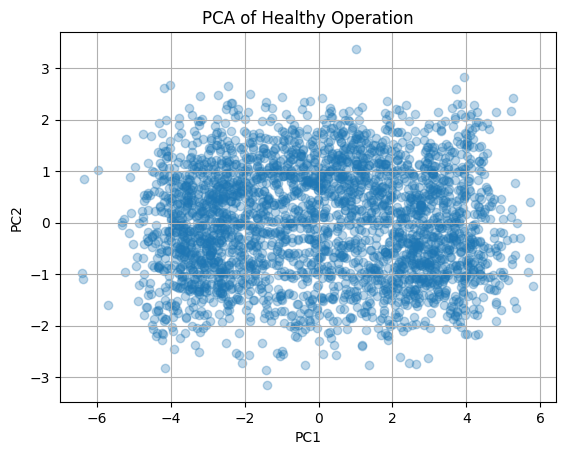

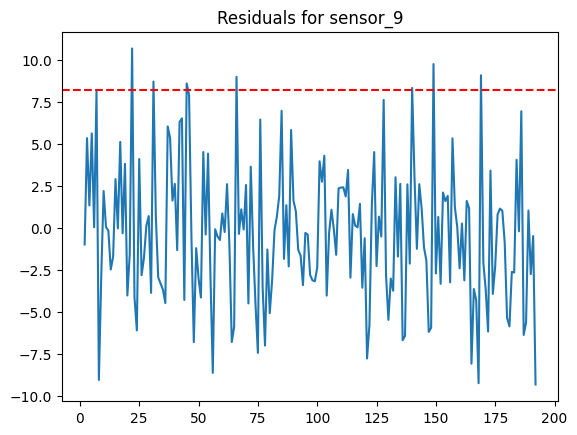

Accuracy on test set: 0.9189696807083445


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8456 - loss: 0.4606 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8875 - loss: 0.3518 - val_accuracy: 0.8887 - val_loss: 0.3493
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8850 - loss: 0.3571 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8870 - loss: 0.3530 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8888 - loss: 0.3494 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8846 - loss: 0.3578 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8835 - loss: 0.3602 - val_accuracy: 0.8887 - val_loss: 0.3496
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8933 - loss: 0.3402 - val_ac

In [8]:
import pandas as pd

df = pd.read_csv("train_FD001.txt", sep=" ", header=None)
df.dropna(axis=1, inplace=True)
columns = ["unit", "time", "op_setting_1", "op_setting_2", "op_setting_3"] + [
    f"sensor_{i}" for i in range(1, 22)
]
df.columns = columns


# We define the first 30 cycles of every engine as "healthy":
healthy_df = df[df["time"] <= 30]
features = [col for col in df.columns if col.startswith("sensor")]
X_healthy = healthy_df[features]

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_healthy)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.title("PCA of Healthy Operation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(False)
plt.savefig("pca_healthy.png")
plt.show()

from scipy.spatial.distance import cdist

X_all_scaled = scaler.transform(df[features])
X_all_pca = pca.transform(X_all_scaled)
center = X_pca.mean(axis=0)
dists = cdist(X_all_pca, [center])
df["pca_distance"] = dists
threshold = dists.mean() + 3 * dists.std()
df["pca_anomaly"] = df["pca_distance"] > threshold


import statsmodels.api as sm

unit_df = df[df["unit"] == 1]
sensor = "sensor_9"
model = sm.tsa.ARIMA(unit_df[sensor], order=(1, 1, 1))
fit = model.fit()
forecast = fit.predict(start=1, end=len(unit_df), dynamic=False)
residuals = unit_df[sensor].iloc[1:].values - forecast[1:]

plt.plot(residuals)
plt.axhline(y=2 * residuals.std(), color="r", linestyle="--")
plt.title(f"Residuals for {sensor}")
plt.savefig("sensor_residuals.png")
plt.show()

from sklearn.ensemble import IsolationForest

X = df[features]
X_scaled = StandardScaler().fit_transform(X)
clf = IsolationForest(contamination=0.05, random_state=42)
df["anomaly_iforest"] = clf.fit_predict(X_scaled)
df["anomaly_iforest"] = df["anomaly_iforest"] == -1


rul_df = df.groupby("unit")["time"].max().reset_index()
rul_df.columns = ["unit", "max_time"]
df = df.merge(rul_df, on="unit")
df["RUL"] = df["max_time"] - df["time"]
df["distress"] = df["RUL"] < 20
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


def make_sequences(df, sensor, window=20):
    sequences = []
    labels = []
    grouped = df.groupby("unit")
    for _, group in grouped:
        values = group[sensor].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


X_seq, y_seq = make_sequences(df, "sensor_9")
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)
print("Accuracy on test set:", clf.score(X_test, y_test))


import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential


def make_lstm_sequences(df, sensor, window=30):
    sequences = []
    labels = []
    grouped = df.groupby("unit")
    for _, group in grouped:
        values = group[sensor].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


X_lstm, y_lstm = make_lstm_sequences(df, "sensor_9")
X_lstm = X_lstm[..., np.newaxis]  # LSTM expects 3D input: (samples, time, features)
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42
)

model = Sequential()
model.add(LSTM(64, input_shape=(X_lstm.shape[1], 1)))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

import tensorflow as tf
from tensorflow.keras.layers import Layer


class Attention(Layer):
    def __init__(self):
        super().__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="random_normal"
        )

    def call(self, inputs):
        scores = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(scores, axis=1)
        output = tf.reduce_sum(inputs * weights, axis=1)
        return output


from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model

input_seq = Input(shape=(X_lstm.shape[1], 1))
x = LSTM(64, return_sequences=True)(input_seq)
x = Attention()(x)
output = Dense(1, activation="sigmoid")(x)
model_attn = Model(inputs=input_seq, outputs=output)
model_attn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_attn.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


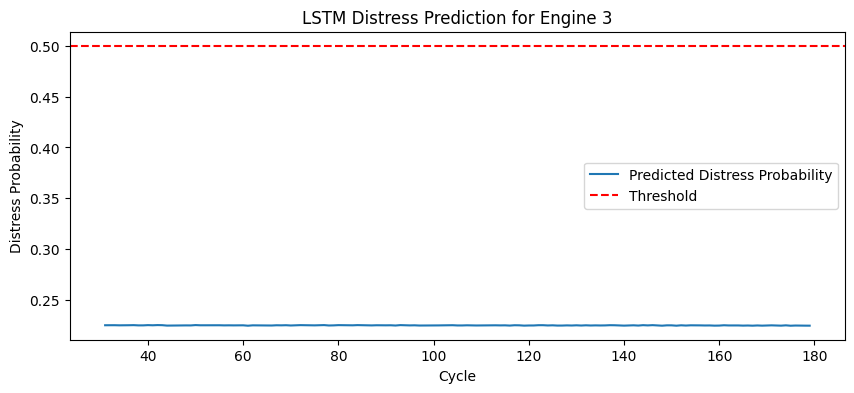

In [18]:
unit_id = 3
unit_data = df[df["unit"] == unit_id].copy()


# Rebuild LSTM sequences from this engine
def make_unit_sequences(unit_data, sensor="sensor_15", window=30):
    values = unit_data[sensor].values
    sequences = [values[i : i + window] for i in range(len(values) - window)]
    return np.array(sequences)[..., np.newaxis]


X_unit = make_unit_sequences(unit_data)
preds = model.predict(X_unit)

# Plot predictions across cycles
import matplotlib.pyplot as plt

cycles = unit_data["time"].values[30:]
plt.figure(figsize=(10, 4))
plt.plot(cycles, preds, label="Predicted Distress Probability")
plt.axhline(0.5, color="red", linestyle="--", label="Threshold")
plt.title(f"LSTM Distress Prediction for Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.savefig("lstm_distress_over_time.png")
plt.show()

In [12]:
class AttentionWithWeights(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="random_normal"
        )

    def call(self, inputs):
        scores = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(scores, axis=1)
        output = tf.reduce_sum(inputs * weights, axis=1)
        return output, weights

In [13]:
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model

input_seq = Input(shape=(X_lstm.shape[1], 1))
x = LSTM(64, return_sequences=True)(input_seq)
context, attn_weights = AttentionWithWeights()(x)
output = Dense(1, activation="sigmoid")(context)

model_attn_vis = Model(inputs=input_seq, outputs=[output, attn_weights])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


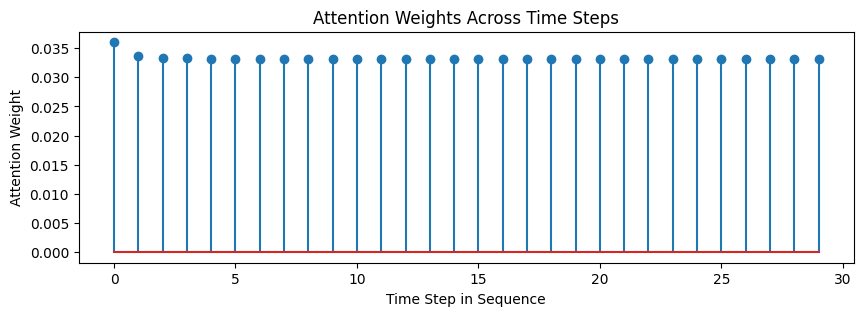

In [15]:
sample = X_lstm[0:1]
pred, attn = model_attn_vis.predict(sample)

attn = attn[0].squeeze()  # shape: (window_size,)
plt.figure(figsize=(10, 3))
plt.stem(range(len(attn)), attn)
plt.title("Attention Weights Across Time Steps")
plt.xlabel("Time Step in Sequence")
plt.ylabel("Attention Weight")
plt.savefig("attention_weights.png")
plt.show()

In [19]:
from tqdm import tqdm

interesting_units = []

sensor = "sensor_15"
window = 30
unit_ids = df["unit"].unique()


def make_unit_sequences(unit_data, sensor="sensor_15", window=30):
    values = unit_data[sensor].values
    sequences = [values[i : i + window] for i in range(len(values) - window)]
    return np.array(sequences)[..., np.newaxis]


for unit_id in tqdm(unit_ids):
    unit_data = df[df["unit"] == unit_id]
    if len(unit_data) <= window:
        continue
    X_unit = make_unit_sequences(unit_data, sensor=sensor, window=window)
    preds = model.predict(X_unit).flatten()
    if preds.size == 0:
        continue
    score = preds.max() - preds.min()
    interesting_units.append((unit_id, score, preds.mean(), preds.std()))

  0%|          | 0/100 [00:00<?, ?it/s]

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


  1%|          | 1/100 [00:00<00:12,  7.91it/s]

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


  2%|▏         | 2/100 [00:00<00:17,  5.57it/s]

...

 98%|█████████▊| 98/100 [00:23<00:00,  3.67it/s]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


 99%|█████████▉| 99/100 [00:23<00:00,  4.13it/s]

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


100%|██████████| 100/100 [00:23<00:00,  4.26it/s]


In [21]:
# Sort descending by prediction range
interesting_units.sort(key=lambda x: x[1], reverse=True)

# Take the most dynamic ones
top_units = interesting_units[:5]

for unit_id, score, mean, std in top_units:
    print(f"Unit {unit_id} | Δ = {score:.3f} | μ = {mean:.3f} | σ = {std:.3f}")

Unit 38 | Δ = 0.001 | μ = 0.225 | σ = 0.000
Unit 53 | Δ = 0.001 | μ = 0.225 | σ = 0.000
Unit 6 | Δ = 0.001 | μ = 0.225 | σ = 0.000
Unit 10 | Δ = 0.001 | μ = 0.225 | σ = 0.000
Unit 78 | Δ = 0.001 | μ = 0.225 | σ = 0.000


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


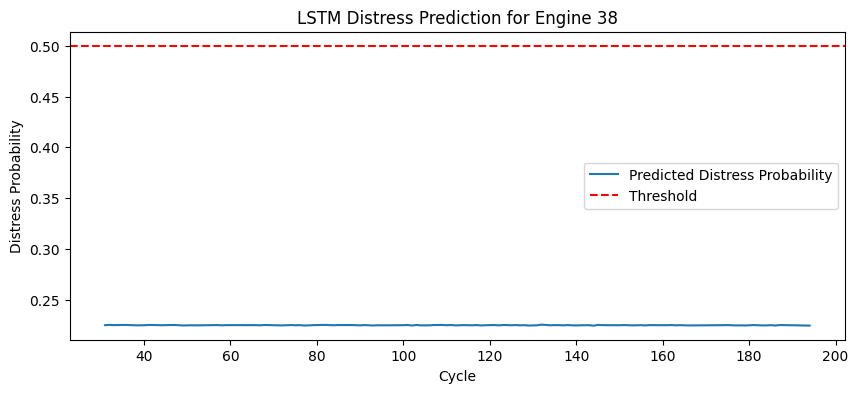

In [24]:
unit_id = top_units[0][0]  # or manually pick an interesting one
unit_data = df[df["unit"] == unit_id].copy()

X_unit = make_unit_sequences(unit_data, sensor=sensor, window=30)
preds = model.predict(X_unit).flatten()
cycles = unit_data["time"].values[30:]

plt.figure(figsize=(10, 4))
plt.plot(cycles, preds, label="Predicted Distress Probability")
plt.axhline(0.5, color="red", linestyle="--", label="Threshold")
plt.title(f"LSTM Distress Prediction for Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.savefig(f"lstm_unit_{unit_id}_interesting.png")
plt.show()

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

sensor = "sensor_9"
window = 30
unit_ids = df["unit"].unique()


def make_unit_sequences(unit_data, sensor, window=30):
    values = unit_data[sensor].values
    if len(values) <= window:
        return np.array([])  # not enough data
    sequences = [values[i : i + window] for i in range(len(values) - window)]
    return np.array(sequences)[..., np.newaxis]


dynamic_units = []

for unit_id in tqdm(unit_ids):
    unit_data = df[df["unit"] == unit_id]
    X_unit = make_unit_sequences(unit_data, sensor=sensor, window=window)
    if X_unit.shape[0] == 0:
        continue
    preds = model.predict(X_unit).flatten()
    # Look for units with meaningful prediction movement
    score = preds.max() - preds.min()
    if score > 0.05:
        dynamic_units.append((unit_id, score, preds))

dynamic_units.sort(key=lambda x: x[1], reverse=True)

  0%|          | 0/100 [00:00<?, ?it/s]


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 1 and 4 for '{{node sequential_1_1/lstm_4_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_1_1/lstm_4_1/strided_slice_1, sequential_1_1/lstm_4_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [32,1], [4,256].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(32, 1), dtype=float32)
  • states=('tf.Tensor(shape=(32, 64), dtype=float32)', 'tf.Tensor(shape=(32, 64), dtype=float32)')
  • training=False

In [35]:
top_unit_id = dynamic_units[0][0]
top_preds = dynamic_units[0][2]

unit_data = df[df["unit"] == top_unit_id].copy()
cycles = unit_data["time"].values[window:]

plt.figure(figsize=(10, 4))
plt.plot(cycles, top_preds, label="Predicted Distress Probability")
plt.axhline(0.5, color="red", linestyle="--", label="Threshold")
plt.title(f"LSTM Distress Prediction for Engine {top_unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.savefig(f"lstm_unit_{top_unit_id}_dynamic.png")
plt.show()

IndexError: list index out of range

In [31]:
import pandas as pd

# Make sure you're only looking at the sensor columns
sensor_cols = [col for col in df.columns if col.startswith("sensor")]

# Compute standard deviation for each sensor
sensor_stats = pd.DataFrame(
    {
        "sensor": sensor_cols,
        "std_dev": [df[col].std() for col in sensor_cols],
        "range": [df[col].max() - df[col].min() for col in sensor_cols],
        "mean": [df[col].mean() for col in sensor_cols],
    }
)

# Sort by standard deviation
sensor_stats = sensor_stats.sort_values(by="std_dev", ascending=False).reset_index(
    drop=True
)

print(sensor_stats)

       sensor       std_dev     range         mean
0    sensor_9  2.208288e+01  222.8600  9065.242941
1   sensor_14  1.907618e+01  193.7800  8143.752722
2    sensor_4  9.000605e+00   59.2400  1408.933782
3    sensor_3  6.131150e+00   45.8700  1590.523119
4   sensor_17  1.548763e+00   12.0000   393.210654
5    sensor_7  8.850923e-01    6.2100   553.367711
6   sensor_12  7.375534e-01    4.6900   521.413470
7    sensor_2  5.000533e-01    3.3200   642.680934
8   sensor_11  2.670874e-01    1.6800    47.541168
9   sensor_20  1.807464e-01    1.2900    38.816271
10  sensor_21  1.082509e-01    0.7242    23.289705
11  sensor_13  7.191892e-02    0.6800  2388.096152
12   sensor_8  7.098548e-02    0.6600  2388.096652
13  sensor_15  3.750504e-02    0.2599     8.442146
14   sensor_6  1.388985e-03    0.0100    21.609803
15   sensor_1  6.537152e-11    0.0000   518.670000
16   sensor_5  3.394700e-12    0.0000    14.620000
17  sensor_10  4.660829e-13    0.0000     1.300000
18  sensor_16  1.556432e-14    

In [36]:
# Select a few high-value sensors
selected_sensors = ["sensor_2", "sensor_3", "sensor_14", "sensor_15"]


def make_multivariate_sequences(df, sensors, window=30):
    sequences = []
    labels = []
    for unit, group in df.groupby("unit"):
        X = group[sensors].values
        y = group["distress"].values
        for i in range(len(X) - window):
            sequences.append(X[i : i + window])
            labels.append(y[i + window])
    return np.array(sequences), np.array(labels)


X_seq, y_seq = make_multivariate_sequences(df, selected_sensors)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


397/397 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.8541 - loss: 0.4735 - val_accuracy: 0.8887 - val_loss: 0.3496
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8905 - loss: 0.3458 - val_accuracy: 0.8887 - val_loss: 0.3493
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8827 - loss: 0.3615 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8840 - loss: 0.3590 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8868 - loss: 0.3532 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8825 - loss: 0.3620 - val_accuracy: 0.8887 - val_loss: 0.3493
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8838 - loss: 0.3596 - val_accuracy: 0.8887 - val_loss: 0.3496
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8860 - loss: 0.3549 - val_accuracy: 0.

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5935 - loss: 0.6325 - val_accuracy: 0.8887 - val_loss: 0.3500
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8905 - loss: 0.3458 - val_accuracy: 0.8887 - val_loss: 0.3496
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8882 - loss: 0.3505 - val_accuracy: 0.8887 - val_loss: 0.3496
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8863 - loss: 0.3542 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8792 - loss: 0.3688 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8902 - loss: 0.3462 - val_accuracy: 0.8887 - val_loss: 0.3502
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8820 - loss: 0.3631 - val_accuracy: 0.8887 - val_loss: 0.3492
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8850 - loss: 0.3572 - val_accuracy: 0.

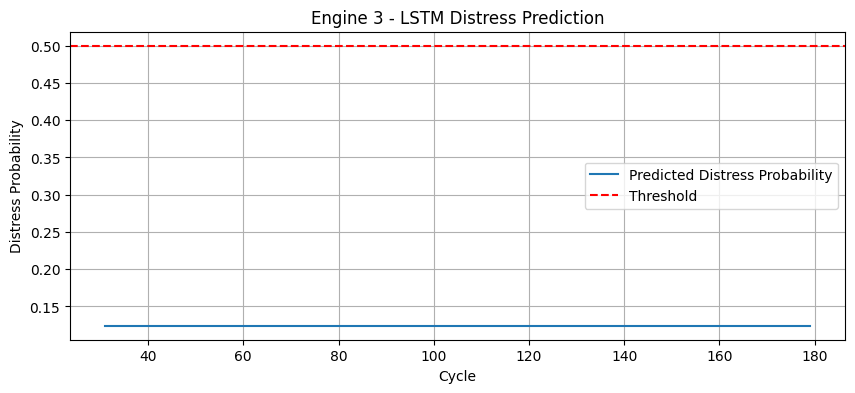

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
df.dropna(axis=1, inplace=True)

# Assign column names
df.columns = ["unit", "time", "op_setting_1", "op_setting_2", "op_setting_3"] + [
    f"sensor_{i}" for i in range(1, 22)
]

# Load RUL file
rul = pd.read_csv("RUL_FD001.txt", header=None)

# Add RUL and distress label
rul.columns = ["max_RUL"]
rul["unit"] = rul.index + 1
last_cycle = df.groupby("unit")["time"].max().reset_index()
last_cycle.columns = ["unit", "max_time"]
df = df.merge(last_cycle, on="unit")
df["RUL"] = df["max_time"] - df["time"]
df["distress"] = df["RUL"] < 20

# Select top volatile sensors based on previous analysis
selected_sensors = [
    "sensor_9",
    "sensor_14",
    "sensor_4",
    "sensor_3",
    "sensor_17",
    "sensor_2",
]


# Create sequences for multivariate LSTM
def make_multivariate_lstm_sequences(df, sensors, window=30):
    sequences = []
    labels = []
    grouped = df.groupby("unit")
    for _, group in grouped:
        X = group[sensors].values
        y = group["distress"].values
        for i in range(len(X) - window):
            sequences.append(X[i : i + window])
            labels.append(y[i + window])
    return np.array(sequences), np.array(labels)


X_seq, y_seq = make_multivariate_lstm_sequences(df, selected_sensors, window=30)

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

# --------------------------------------
# Model 1: Plain Multivariate LSTM
# --------------------------------------
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# --------------------------------------
# Model 2: LSTM + Attention
# --------------------------------------
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
from tensorflow.keras.models import Model


class Attention(Layer):
    def __init__(self):
        super().__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="random_normal"
        )

    def call(self, inputs):
        scores = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(scores, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context


input_seq = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = LSTM(64, return_sequences=True)(input_seq)
x = Attention()(x)
output = Dense(1, activation="sigmoid")(x)

model_attn = Model(inputs=input_seq, outputs=output)
model_attn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_attn.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)


# --------------------------------------
# Predicting for one engine and plotting
# --------------------------------------
def predict_and_plot(model, unit_id=3, window=30):
    unit_data = df[df["unit"] == unit_id].copy()
    values = unit_data[selected_sensors].values
    sequences = [values[i : i + window] for i in range(len(values) - window)]
    X_unit = np.array(sequences)
    preds = model.predict(X_unit).flatten()
    cycles = unit_data["time"].values[window:]

    plt.figure(figsize=(10, 4))
    plt.plot(cycles, preds, label="Predicted Distress Probability")
    plt.axhline(0.5, color="red", linestyle="--", label="Threshold")
    plt.title(f"Engine {unit_id} - LSTM Distress Prediction")
    plt.xlabel("Cycle")
    plt.ylabel("Distress Probability")
    plt.legend()
    plt.grid(True)
    plt.show()


# Run for one engine
predict_and_plot(model_attn, unit_id=3)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


397/397 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.8906 - loss: 0.2159 - val_accuracy: 0.9688 - val_loss: 0.0741
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9722 - loss: 0.0711 - val_accuracy: 0.9794 - val_loss: 0.0531
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9705 - loss: 0.0644 - val_accuracy: 0.9780 - val_loss: 0.0592
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9714 - loss: 0.0628 - val_accuracy: 0.9809 - val_loss: 0.0479
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9725 - loss: 0.0619 - val_accuracy: 0.9816 - val_loss: 0.0451
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9772 - loss: 0.0538 - val_accuracy: 0.9794 - val_loss: 0.0476
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9760 - loss: 0.0556 - val_accuracy: 0.9695 - val_loss: 0.0663
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9770 - loss: 0.0529 - val_accuracy: 0.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


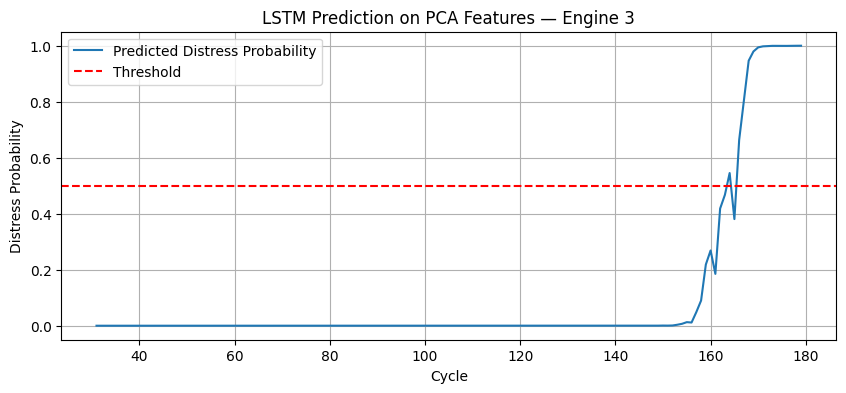

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load dataset
df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
df.dropna(axis=1, inplace=True)
df.columns = ["unit", "time", "op_setting_1", "op_setting_2", "op_setting_3"] + [
    f"sensor_{i}" for i in range(1, 22)
]

# 2. Compute RUL and distress labels
rul = pd.read_csv("RUL_FD001.txt", header=None)
rul.columns = ["max_RUL"]
rul["unit"] = rul.index + 1
last_cycle = df.groupby("unit")["time"].max().reset_index()
last_cycle.columns = ["unit", "max_time"]
df = df.merge(last_cycle, on="unit")
df["RUL"] = df["max_time"] - df["time"]
df["distress"] = df["RUL"] < 20

# 3. Select top 6 volatile sensors (based on std/range/IQR)
selected_sensors = [
    "sensor_9",
    "sensor_14",
    "sensor_4",
    "sensor_3",
    "sensor_17",
    "sensor_2",
]

# 4. Standardize and apply PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sensor_data = df[selected_sensors]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(sensor_data)

pca = PCA(n_components=3)
pca_factors = pca.fit_transform(scaled_data)

df["pca_1"] = pca_factors[:, 0]
df["pca_2"] = pca_factors[:, 1]
df["pca_3"] = pca_factors[:, 2]


# 5. Create sequences for PCA-based LSTM
def make_pca_lstm_sequences(df, pca_cols, window=30):
    sequences = []
    labels = []
    grouped = df.groupby("unit")
    for _, group in grouped:
        values = group[pca_cols].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


pca_columns = ["pca_1", "pca_2", "pca_3"]
X_pca_seq, y_pca_seq = make_pca_lstm_sequences(df, pca_columns, window=30)

# 6. Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca_seq, y_pca_seq, test_size=0.2, random_state=42
)

# 7. LSTM model using PCA factors
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)


# 8. Predict for one engine and plot distress over time
def predict_and_plot(model, unit_id=3, window=30):
    unit_data = df[df["unit"] == unit_id].copy()
    values = unit_data[pca_columns].values
    sequences = [values[i : i + window] for i in range(len(values) - window)]
    X_unit = np.array(sequences)
    preds = model.predict(X_unit).flatten()
    cycles = unit_data["time"].values[window:]

    plt.figure(figsize=(10, 4))
    plt.plot(cycles, preds, label="Predicted Distress Probability")
    plt.axhline(0.5, color="red", linestyle="--", label="Threshold")
    plt.title(f"LSTM Prediction on PCA Features — Engine {unit_id}")
    plt.xlabel("Cycle")
    plt.ylabel("Distress Probability")
    plt.legend()
    plt.grid(True)
    plt.show()


predict_and_plot(model, unit_id=3)

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
from tensorflow.keras.models import Model


# Define Attention layer that returns both context and weights
class AttentionWithWeights(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="random_normal"
        )

    def call(self, inputs):
        scores = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(scores, axis=1)
        output = tf.reduce_sum(inputs * weights, axis=1)
        return output, weights


# Build attention model using PCA inputs
input_seq = Input(shape=(X_train.shape[1], X_train.shape[2]))  # (30, 3)
x = LSTM(64, return_sequences=True)(input_seq)
context, attn_weights = AttentionWithWeights()(x)
output = Dense(1, activation="sigmoid")(context)

model_attn_vis = Model(inputs=input_seq, outputs=[output, attn_weights])
model_attn_vis.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

# Train the attention model
model_attn_vis.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Choose one example to visualize attention (e.g. from engine 3)
unit_id = 3
unit_data = df[df["unit"] == unit_id].copy()
pca_cols = ["pca_1", "pca_2", "pca_3"]
values = unit_data[pca_cols].values
sequences = [values[i : i + 30] for i in range(len(values) - 30)]
X_unit = np.array(sequences)

# Predict and get attention weights
sample = X_unit[0:1]
pred, attn = model_attn_vis.predict(sample)
attn = attn[0].squeeze()

# Plot attention weights
plt.figure(figsize=(10, 3))
plt.stem(range(len(attn)), attn, use_line_collection=True)
plt.title("Attention Weights Across Time Steps")
plt.xlabel("Time Step in Sequence")
plt.ylabel("Attention Weight")
plt.grid(True)
plt.savefig("attention_weights_pca.png")
plt.show()

Epoch 1/10


KeyError: "The path: (0,) in the `loss` argument, can't be found in either the model's output (`y_pred`) or in the labels (`y_true`)."

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9018 - loss: 0.2306 - val_accuracy: 0.9738 - val_loss: 0.0634
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9692 - loss: 0.0762 - val_accuracy: 0.9745 - val_loss: 0.0602
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9719 - loss: 0.0639 - val_accuracy: 0.9780 - val_loss: 0.0539
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9733 - loss: 0.0621 - val_accuracy: 0.9780 - val_loss: 0.0481
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9736 - loss: 0.0589 - val_accuracy: 0.9816 - val_loss: 0.0464
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9725 - loss: 0.0599 - val_accuracy: 0.9695 - val_loss: 0.0570
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9760 - loss: 0.0558 - val_accuracy: 0.9773 - val_loss: 0.0541
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9731 - loss: 0.0580 - val_accuracy: 0.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


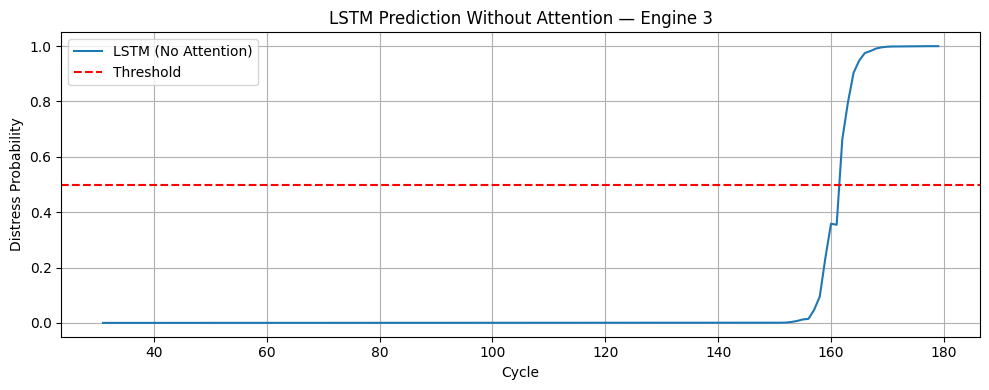

In [45]:
# Create PCA-based sequences
pca_cols = ["pca_1", "pca_2", "pca_3"]


def make_pca_lstm_sequences(df, pca_cols, window=30):
    sequences, labels = [], []
    for _, group in df.groupby("unit"):
        values = group[pca_cols].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


X, y = make_pca_lstm_sequences(df, pca_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential

# Basic LSTM model
model_plain = Sequential()
model_plain.add(LSTM(64, input_shape=(X.shape[1], X.shape[2])))
model_plain.add(Dense(1, activation="sigmoid"))

model_plain.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_plain.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Predict for engine 3
unit_id = 3
window = 30
engine_data = df[df["unit"] == unit_id].copy()
X_engine = np.array(
    [
        engine_data[pca_cols].values[i : i + window]
        for i in range(len(engine_data) - window)
    ]
)
cycles = engine_data["time"].values[window:]

preds_plain = model_plain.predict(X_engine).flatten()

# Plot without attention
plt.figure(figsize=(10, 4))
plt.plot(cycles, preds_plain, label="LSTM (No Attention)")
plt.axhline(0.5, color="red", linestyle="--", label="Threshold")
plt.title(f"LSTM Prediction Without Attention — Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("distress_prediction_no_attention.png")
plt.show()

In [46]:
# predictive_maintenance.py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
from tensorflow.keras.models import Model, Sequential

# -----------------------------
# Load and preprocess data
# -----------------------------
df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
df.dropna(axis=1, inplace=True)
df.columns = ["unit", "time", "op_setting_1", "op_setting_2", "op_setting_3"] + [
    f"sensor_{i}" for i in range(1, 22)
]

rul = pd.read_csv("RUL_FD001.txt", header=None)
rul.columns = ["max_RUL"]
rul["unit"] = rul.index + 1
last_cycle = df.groupby("unit")["time"].max().reset_index()
last_cycle.columns = ["unit", "max_time"]
df = df.merge(last_cycle, on="unit")
df["RUL"] = df["max_time"] - df["time"]
df["distress"] = df["RUL"] < 20

selected_sensors = [
    "sensor_9",
    "sensor_14",
    "sensor_4",
    "sensor_3",
    "sensor_17",
    "sensor_2",
]

# -----------------------------
# PCA (Single Transformation)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[selected_sensors])
pca = PCA(n_components=3)
pca_factors = pca.fit_transform(X_scaled)
df[["pca_1", "pca_2", "pca_3"]] = pca_factors

# -----------------------------
# PCA for Healthy Boundaries (Visualization)
# -----------------------------
healthy_df = df[df["time"] <= 30]
X_pca = healthy_df[["pca_1", "pca_2"]].values
center = X_pca.mean(axis=0)
df["pca_distance"] = np.linalg.norm(df[["pca_1", "pca_2"]].values - center, axis=1)
threshold = df["pca_distance"].mean() + 3 * df["pca_distance"].std()
df["pca_anomaly"] = df["pca_distance"] > threshold

plt.figure(figsize=(8, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.title("PCA of Healthy Operation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.savefig("pca_healthy_bounds.png")
plt.close()

# -----------------------------
# Time Series Modeling (ARIMA with PCA)
# -----------------------------
unit_df = df[df["unit"] == 1]
model = sm.tsa.ARIMA(unit_df["pca_1"], order=(1, 1, 1))
fit = model.fit()
forecast = fit.predict(start=1, end=len(unit_df), dynamic=False)
residuals = unit_df["pca_1"].iloc[1:].values - forecast[1:]

plt.figure(figsize=(8, 4))
plt.plot(residuals)
plt.axhline(y=2 * residuals.std(), color="r", linestyle="--")
plt.title("ARIMA Residuals on PCA_1")
plt.savefig("arima_residuals_pca1.png")
plt.close()

# -----------------------------
# Anomaly Detection (Isolation Forest on PCA)
# -----------------------------
pca_features = df[["pca_1", "pca_2", "pca_3"]].values
clf = IsolationForest(contamination=0.05, random_state=42)
df["anomaly_iforest"] = clf.fit_predict(pca_features) == -1

plt.figure(figsize=(8, 4))
plt.hist(df["pca_distance"], bins=50, alpha=0.6, label="PCA Distance")
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Isolation Forest Anomalies")
plt.legend()
plt.savefig("iforest_anomaly_pca.png")
plt.close()


# -----------------------------
# Sequence Classification (Random Forest)
# -----------------------------
def make_sequences(df, sensor, window=30):
    sequences, labels = [], []
    for _, group in df.groupby("unit"):
        values = group[sensor].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


X_seq, y_seq = make_sequences(df, "sensor_9")
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)
rf_clf = RandomForestClassifier(n_estimators=100)
rf_clf.fit(X_train_rf, y_train_rf)


# -----------------------------
# PCA-based LSTM
# -----------------------------
def make_pca_lstm_sequences(df, pca_cols, window=30):
    sequences, labels = [], []
    for _, group in df.groupby("unit"):
        values = group[pca_cols].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


pca_cols = ["pca_1", "pca_2", "pca_3"]
X, y = make_pca_lstm_sequences(df, pca_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(64, input_shape=(X.shape[1], X.shape[2])))
model_lstm.add(Dense(1, activation="sigmoid"))
model_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)


# -----------------------------
# LSTM + Attention
# -----------------------------
class AttentionWithWeights(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="random_normal"
        )

    def call(self, inputs):
        scores = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(scores, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context, weights


input_seq = Input(shape=(X.shape[1], X.shape[2]))
x = LSTM(64, return_sequences=True)(input_seq)
context, attn_weights = AttentionWithWeights()(x)
output = Dense(1, activation="sigmoid")(context)

model_attn = Model(inputs=input_seq, outputs=[output, attn_weights])
model_attn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_attn.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

print("Training complete. All models and visualizations are ready.")

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


397/397 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8891 - loss: 0.2250 - val_accuracy: 0.9745 - val_loss: 0.0675
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9709 - loss: 0.0689 - val_accuracy: 0.9745 - val_loss: 0.0595
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9732 - loss: 0.0659 - val_accuracy: 0.9766 - val_loss: 0.0571
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9744 - loss: 0.0580 - val_accuracy: 0.9823 - val_loss: 0.0453
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9742 - loss: 0.0583 - val_accuracy: 0.9787 - val_loss: 0.0479
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9754 - loss: 0.0578 - val_accuracy: 0.9794 - val_loss: 0.0491
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9763 - loss: 0.0548 - val_accuracy: 0.9681 - val_loss: 0.0568
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9741 - loss: 0.0539 - val_accuracy: 0.983

KeyError: "The path: (0,) in the `loss` argument, can't be found in either the model's output (`y_pred`) or in the labels (`y_true`)."

In [49]:
# predictive_maintenance.py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
from tensorflow.keras.models import Model, Sequential

# -----------------------------
# Load and preprocess data
# -----------------------------
df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
df.dropna(axis=1, inplace=True)
df.columns = ["unit", "time", "op_setting_1", "op_setting_2", "op_setting_3"] + [
    f"sensor_{i}" for i in range(1, 22)
]

rul = pd.read_csv("RUL_FD001.txt", header=None)
rul.columns = ["max_RUL"]
rul["unit"] = rul.index + 1
last_cycle = df.groupby("unit")["time"].max().reset_index()
last_cycle.columns = ["unit", "max_time"]
df = df.merge(last_cycle, on="unit")
df["RUL"] = df["max_time"] - df["time"]
df["distress"] = df["RUL"] < 20

selected_sensors = [
    "sensor_9",
    "sensor_14",
    "sensor_4",
    "sensor_3",
    "sensor_17",
    "sensor_2",
]

# -----------------------------
# PCA (Single Transformation)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[selected_sensors])
pca = PCA(n_components=3)
pca_factors = pca.fit_transform(X_scaled)
df[["pca_1", "pca_2", "pca_3"]] = pca_factors

# -----------------------------
# PCA for Healthy Boundaries (Visualization)
# -----------------------------
healthy_df = df[df["time"] <= 30]
X_pca = healthy_df[["pca_1", "pca_2"]].values
center = X_pca.mean(axis=0)
df["pca_distance"] = np.linalg.norm(df[["pca_1", "pca_2"]].values - center, axis=1)
threshold = df["pca_distance"].mean() + 3 * df["pca_distance"].std()
df["pca_anomaly"] = df["pca_distance"] > threshold

plt.figure(figsize=(8, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.title("PCA of Healthy Operation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.savefig("pca_healthy_bounds.png")
plt.close()

# -----------------------------
# Time Series Modeling (ARIMA with PCA)
# -----------------------------
unit_df = df[df["unit"] == 1]
model = sm.tsa.ARIMA(unit_df["pca_1"], order=(1, 1, 1))
fit = model.fit()
forecast = fit.predict(start=1, end=len(unit_df), dynamic=False)
residuals = unit_df["pca_1"].iloc[1:].values - forecast[1:]

plt.figure(figsize=(8, 4))
plt.plot(residuals)
plt.axhline(y=2 * residuals.std(), color="r", linestyle="--")
plt.title("ARIMA Residuals on PCA_1")
plt.savefig("arima_residuals_pca1.png")
plt.close()

# -----------------------------
# Anomaly Detection (Isolation Forest on PCA)
# -----------------------------
pca_features = df[["pca_1", "pca_2", "pca_3"]].values
clf = IsolationForest(contamination=0.05, random_state=42)
df["anomaly_iforest"] = clf.fit_predict(pca_features) == -1

plt.figure(figsize=(8, 4))
plt.hist(df["pca_distance"], bins=50, alpha=0.6, label="PCA Distance")
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Isolation Forest Anomalies")
plt.legend()
plt.savefig("iforest_anomaly_pca.png")
plt.close()


# -----------------------------
# Sequence Classification (Random Forest)
# -----------------------------
def make_sequences(df, sensor, window=30):
    sequences, labels = [], []
    for _, group in df.groupby("unit"):
        values = group[sensor].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


X_seq, y_seq = make_sequences(df, "sensor_9")
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)
rf_clf = RandomForestClassifier(n_estimators=100)
rf_clf.fit(X_train_rf, y_train_rf)

# Visualization of prediction probabilities
y_pred_rf = rf_clf.predict_proba(X_test_rf)[:, 1]
plt.figure(figsize=(8, 4))
plt.hist(y_pred_rf, bins=30, alpha=0.7)
plt.title("Random Forest Distress Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.savefig("rf_sequence_classification.png")
plt.close()


# -----------------------------
# PCA-based LSTM
# -----------------------------
def make_pca_lstm_sequences(df, pca_cols, window=30):
    sequences, labels = [], []
    for _, group in df.groupby("unit"):
        values = group[pca_cols].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


pca_cols = ["pca_1", "pca_2", "pca_3"]
X, y = make_pca_lstm_sequences(df, pca_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(64, input_shape=(X.shape[1], X.shape[2])))
model_lstm.add(Dense(1, activation="sigmoid"))
model_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

pred_lstm = model_lstm.predict(X_test).flatten()
plt.figure(figsize=(8, 4))
plt.plot(pred_lstm, alpha=0.8)
plt.title("LSTM Distress Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Probability")
plt.savefig("lstm_predictions.png")
plt.close()


# -----------------------------
# LSTM + Attention
# -----------------------------
class AttentionWithWeights(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="random_normal"
        )

    def call(self, inputs):
        scores = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(scores, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context, weights


input_seq = Input(shape=(X.shape[1], X.shape[2]))
x = LSTM(64, return_sequences=True)(input_seq)
context, attn_weights = AttentionWithWeights()(x)
output = Dense(1, activation="sigmoid", name="pred")(context)
model_attn = Model(inputs=input_seq, outputs={"pred": output, "attn": attn_weights})
model_attn.compile(
    optimizer="adam", loss={"pred": "binary_crossentropy"}, metrics={"pred": "accuracy"}
)

model_attn.fit(
    X_train, {"pred": y_train}, epochs=10, batch_size=32, validation_split=0.1
)

# Predict
pred_dict = model_attn.predict(X_test)
pred_attn = pred_dict["pred"]
attn = pred_dict["attn"]

# Plot predictions
plt.figure(figsize=(8, 4))
plt.plot(pred_attn.flatten(), alpha=0.8)
plt.title("LSTM + Attention Distress Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Probability")
plt.savefig("lstm_attention_predictions.png")
plt.close()


print("Training complete. All models and visualizations are ready.")

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


397/397 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8936 - loss: 0.2227 - val_accuracy: 0.9773 - val_loss: 0.0659
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9715 - loss: 0.0692 - val_accuracy: 0.9794 - val_loss: 0.0506
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9697 - loss: 0.0683 - val_accuracy: 0.9816 - val_loss: 0.0491
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9720 - loss: 0.0603 - val_accuracy: 0.9844 - val_loss: 0.0465
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9747 - loss: 0.0598 - val_accuracy: 0.9759 - val_loss: 0.0537
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9720 - loss: 0.0631 - val_accuracy: 0.9702 - val_loss: 0.0553
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9767 - loss: 0.0534 - val_accuracy: 0.9823 - val_loss: 0.0464
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9761 - loss: 0.0538 - val_accuracy:

In [50]:
# For a specific engine
unit_id = 3
unit_data = df[df["unit"] == unit_id].copy()
X_unit = np.array(
    [unit_data[pca_cols].values[i : i + 30] for i in range(len(unit_data) - 30)]
)
cycles = unit_data["time"].values[30:]

# For plain LSTM
preds_plain = model_lstm.predict(X_unit).flatten()

# For attention model
preds_dict = model_attn.predict(X_unit)
preds_attn = preds_dict["pred"].flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


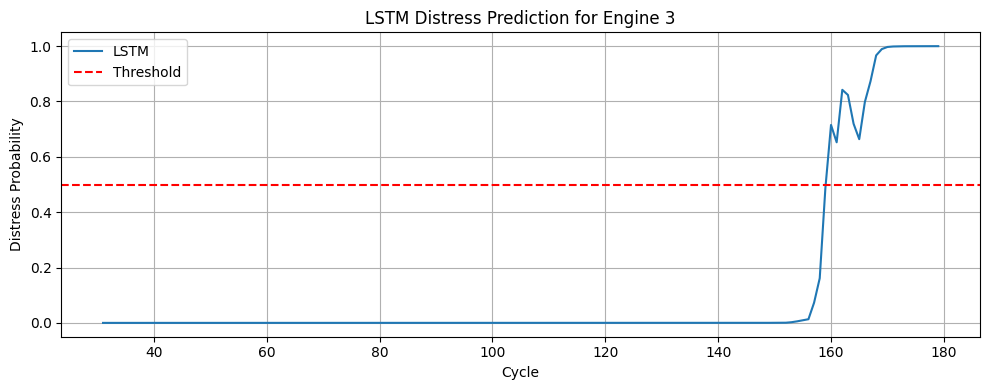

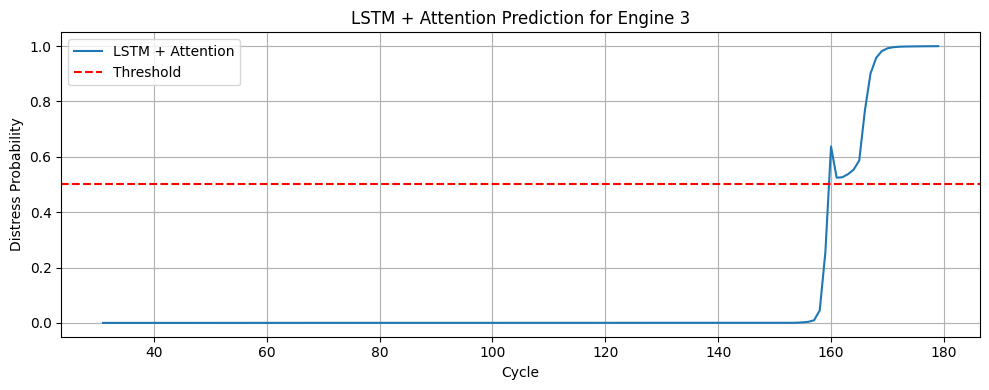

In [51]:
# LSTM
plt.figure(figsize=(10, 4))
plt.plot(cycles, preds_plain, label="LSTM")
plt.axhline(0.5, color="red", linestyle="--", label="Threshold")
plt.title(f"LSTM Distress Prediction for Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lstm_engine_prediction.png")
plt.show()

# LSTM + Attention
plt.figure(figsize=(10, 4))
plt.plot(cycles, preds_attn, label="LSTM + Attention")
plt.axhline(0.5, color="red", linestyle="--", label="Threshold")
plt.title(f"LSTM + Attention Prediction for Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lstm_attention_engine_prediction.png")
plt.show()

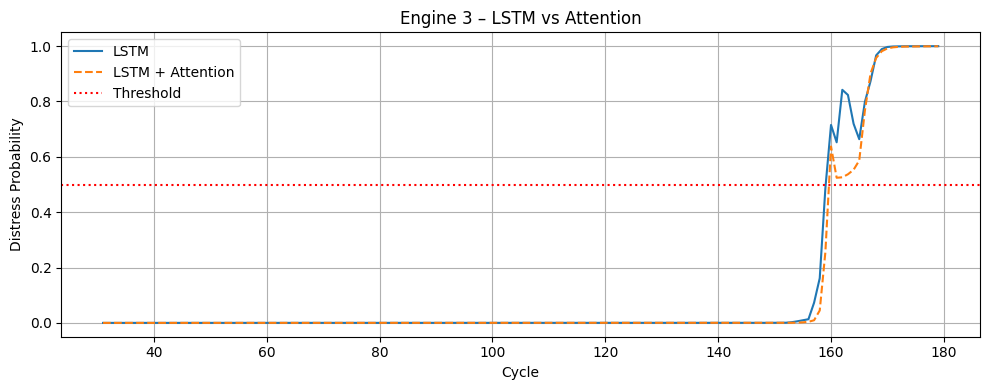

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(cycles, preds_plain, label="LSTM")
plt.plot(cycles, preds_attn, label="LSTM + Attention", linestyle="--")
plt.axhline(0.5, color="red", linestyle=":", label="Threshold")
plt.title(f"Engine {unit_id} – LSTM vs Attention")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("comparison_lstm_vs_attention.png")
plt.show()

In [53]:
# predictive_maintenance.py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
from tensorflow.keras.models import Model, Sequential

# Custom minimalist plot style
plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

# -----------------------------
# Load and preprocess data
# -----------------------------
df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
df.dropna(axis=1, inplace=True)
df.columns = ["unit", "time", "op_setting_1", "op_setting_2", "op_setting_3"] + [
    f"sensor_{i}" for i in range(1, 22)
]

rul = pd.read_csv("RUL_FD001.txt", header=None)
rul.columns = ["max_RUL"]
rul["unit"] = rul.index + 1
last_cycle = df.groupby("unit")["time"].max().reset_index()
last_cycle.columns = ["unit", "max_time"]
df = df.merge(last_cycle, on="unit")
df["RUL"] = df["max_time"] - df["time"]
df["distress"] = df["RUL"] < 20

selected_sensors = [
    "sensor_9",
    "sensor_14",
    "sensor_4",
    "sensor_3",
    "sensor_17",
    "sensor_2",
]

# -----------------------------
# PCA
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[selected_sensors])
pca = PCA(n_components=3)
pca_factors = pca.fit_transform(X_scaled)
df[["pca_1", "pca_2", "pca_3"]] = pca_factors

# -----------------------------
# PCA for Healthy Boundaries (Visualization)
# -----------------------------
healthy_df = df[df["time"] <= 30]
X_pca = healthy_df[["pca_1", "pca_2"]].values
center = X_pca.mean(axis=0)
df["pca_distance"] = np.linalg.norm(df[["pca_1", "pca_2"]].values - center, axis=1)
threshold = df["pca_distance"].mean() + 3 * df["pca_distance"].std()
df["pca_anomaly"] = df["pca_distance"] > threshold

plt.figure(figsize=(8, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.title("PCA of Healthy Operation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(False)
plt.savefig("pca_healthy_bounds.png")
plt.close()

# -----------------------------
# Time Series Modeling (ARIMA with PCA)
# -----------------------------
unit_df = df[df["unit"] == 1]
model = sm.tsa.ARIMA(unit_df["pca_1"], order=(1, 1, 1))
fit = model.fit()
forecast = fit.predict(start=1, end=len(unit_df), dynamic=False)
residuals = unit_df["pca_1"].iloc[1:].values - forecast[1:]

plt.figure(figsize=(8, 4))
plt.plot(residuals)
plt.axhline(y=2 * residuals.std(), color="r", linestyle="--")
plt.title("ARIMA Residuals on PCA_1")
plt.savefig("arima_residuals_pca1.png")
plt.close()

# -----------------------------
# Anomaly Detection (Isolation Forest on PCA)
# -----------------------------
pca_features = df[["pca_1", "pca_2", "pca_3"]].values
clf = IsolationForest(contamination=0.05, random_state=42)
df["anomaly_iforest"] = clf.fit_predict(pca_features) == -1

plt.figure(figsize=(8, 4))
plt.hist(df["pca_distance"], bins=50, alpha=0.6, label="PCA Distance")
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Isolation Forest Anomalies")
plt.legend()
plt.savefig("iforest_anomaly_pca.png")
plt.close()


# -----------------------------
# Sequence Classification (Random Forest)
# -----------------------------
def make_sequences(df, sensor, window=30):
    sequences, labels = [], []
    for _, group in df.groupby("unit"):
        values = group[sensor].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


X_seq, y_seq = make_sequences(df, "sensor_9")
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)
rf_clf = RandomForestClassifier(n_estimators=100)
rf_clf.fit(X_train_rf, y_train_rf)

# Visualization of prediction probabilities
y_pred_rf = rf_clf.predict_proba(X_test_rf)[:, 1]
plt.figure(figsize=(8, 4))
plt.hist(y_pred_rf, bins=30, alpha=0.7)
plt.title("Random Forest Distress Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.savefig("rf_sequence_classification.png")
plt.close()


# -----------------------------
# PCA-based LSTM
# -----------------------------
def make_pca_lstm_sequences(df, pca_cols, window=30):
    sequences, labels = [], []
    for _, group in df.groupby("unit"):
        values = group[pca_cols].values
        targets = group["distress"].values
        for i in range(len(values) - window):
            sequences.append(values[i : i + window])
            labels.append(targets[i + window])
    return np.array(sequences), np.array(labels)


pca_cols = ["pca_1", "pca_2", "pca_3"]
X, y = make_pca_lstm_sequences(df, pca_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(64, input_shape=(X.shape[1], X.shape[2])))
model_lstm.add(Dense(1, activation="sigmoid"))
model_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

pred_lstm = model_lstm.predict(X_test).flatten()
plt.figure(figsize=(8, 4))
plt.plot(pred_lstm, alpha=0.8)
plt.title("LSTM Distress Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Probability")
plt.savefig("lstm_predictions.png")
plt.close()


# -----------------------------
# LSTM + Attention
# -----------------------------
class AttentionWithWeights(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="random_normal"
        )

    def call(self, inputs):
        scores = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(scores, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context, weights


input_seq = Input(shape=(X.shape[1], X.shape[2]))
x = LSTM(64, return_sequences=True)(input_seq)
context, attn_weights = AttentionWithWeights()(x)
output = Dense(1, activation="sigmoid", name="pred")(context)
model_attn = Model(inputs=input_seq, outputs={"pred": output, "attn": attn_weights})
model_attn.compile(
    optimizer="adam", loss={"pred": "binary_crossentropy"}, metrics={"pred": "accuracy"}
)

model_attn.fit(
    X_train, {"pred": y_train}, epochs=10, batch_size=32, validation_split=0.1
)


# Predict and compare for a specific engine
unit_id = 3
window = 30
engine_data = df[df["unit"] == unit_id].copy()
X_engine = np.array(
    [
        engine_data[["pca_1", "pca_2", "pca_3"]].values[i : i + window]
        for i in range(len(engine_data) - window)
    ]
)
cycles = engine_data["time"].values[window:]

# LSTM prediction
pred_lstm_engine = model_lstm.predict(X_engine).flatten()

# LSTM + Attention prediction
pred_dict = model_attn.predict(X_engine)
pred_attn_engine = pred_dict["pred"].flatten()

# Plot LSTM only
plt.figure(figsize=(10, 4))
plt.plot(cycles, pred_lstm_engine, label="LSTM")
plt.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Threshold")
plt.title(f"LSTM Distress Prediction for Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_engine_prediction.png")
plt.close()

# Plot LSTM + Attention only
plt.figure(figsize=(10, 4))
plt.plot(cycles, pred_attn_engine, label="LSTM + Attention")
plt.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Threshold")
plt.title(f"LSTM + Attention Prediction for Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_attention_engine_prediction.png")
plt.close()

# Combined comparison
plt.figure(figsize=(10, 4))
plt.plot(cycles, pred_lstm_engine, label="LSTM")
plt.plot(cycles, pred_attn_engine, label="LSTM + Attention", linestyle="--")
plt.axhline(0.5, color="red", linestyle=":", linewidth=0.8, label="Threshold")
plt.title(f"Engine {unit_id} – LSTM vs Attention")
plt.xlabel("Cycle")
plt.ylabel("Distress Probability")
plt.legend()
plt.tight_layout()
plt.savefig("comparison_lstm_vs_attention.png")
plt.close()

print("Engine-specific visualizations complete.")

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


397/397 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8968 - loss: 0.2115 - val_accuracy: 0.9773 - val_loss: 0.0685
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9700 - loss: 0.0738 - val_accuracy: 0.9809 - val_loss: 0.0579
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9742 - loss: 0.0636 - val_accuracy: 0.9794 - val_loss: 0.0514
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9736 - loss: 0.0609 - val_accuracy: 0.9844 - val_loss: 0.0456
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9746 - loss: 0.0605 - val_accuracy: 0.9816 - val_loss: 0.0458
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9757 - loss: 0.0544 - val_accuracy: 0.9766 - val_loss: 0.0497
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9753 - loss: 0.0595 - val_accuracy: 0.9780 - val_loss: 0.0476
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9774 - loss: 0.0524 - val_accuracy: 0.97

In [54]:
healthy_df = df[df["time"] <= 30]
X_pca = healthy_df[["pca_1", "pca_2"]].values
center = X_pca.mean(axis=0)
df["pca_distance"] = np.linalg.norm(df[["pca_1", "pca_2"]].values - center, axis=1)
threshold = df["pca_distance"].mean() + 3 * df["pca_distance"].std()
df["pca_anomaly"] = df["pca_distance"] > threshold

plt.figure(figsize=(8, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.title("PCA of Healthy Operation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(False)
plt.savefig("pca_healthy_bounds.png")
plt.close()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


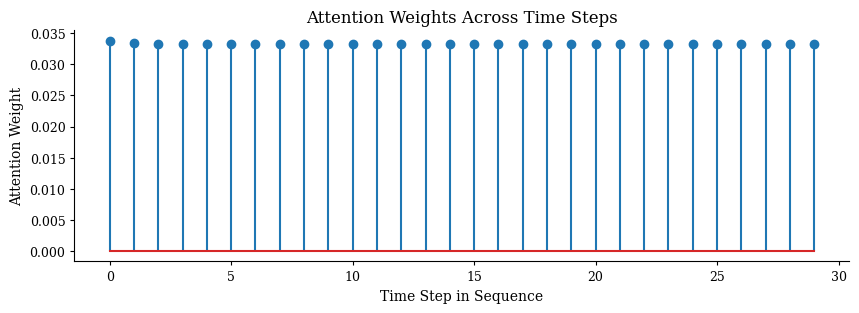

In [56]:
class AttentionWithWeights(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="random_normal"
        )

    def call(self, inputs):
        scores = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(scores, axis=1)
        output = tf.reduce_sum(inputs * weights, axis=1)
        return output, weights


from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model

input_seq = Input(shape=(X_lstm.shape[1], 1))
x = LSTM(64, return_sequences=True)(input_seq)
context, attn_weights = AttentionWithWeights()(x)
output = Dense(1, activation="sigmoid")(context)
model_attn_vis = Model(inputs=input_seq, outputs=[output, attn_weights])
sample = X_lstm[0:1]
pred, attn = model_attn_vis.predict(sample)
attn = attn[0].squeeze()  # shape: (window_size,)
plt.figure(figsize=(10, 3))
plt.stem(range(len(attn)), attn)
plt.title("Attention Weights Across Time Steps")
plt.xlabel("Time Step in Sequence")
plt.ylabel("Attention Weight")
plt.savefig("attention_weights.png")
plt.show()

In [57]:
from openai import OpenAI

prompt = """
You are looking at a time series forecasting model for sensor_9 from a jet engine.
The model starts to deviate significantly from actual values after cycle 150.
What might cause this, and what could you try to improve it?
"""
# Pseudo-code for LLM interaction
response = openai.ChatCompletion.create(
    model="gpt-4", messages=[{"role": "user", "content": prompt}]
)
print(response["choices"][0]["message"]["content"])

NameError: name 'openai' is not defined